In [ ]:
from dotenv import load_dotenv

load_dotenv()

True

In [33]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    answer: str
    tax_base_equation: str
    tax_deduction: str
    tax_base: str

graph_builder = StateGraph(AgentState)

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=100,
    separators=['\n\n', '\n']
)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from langchain_community.document_loaders import TextLoader

text_path = './documents/real_estate_tax.txt'
loader = TextLoader(text_path)
document_list = loader.load_and_split(text_splitter)

/var/folders/8l/ylr41sxs3_l9cwqgdmznm12h0000gn/T/ipykernel_8739/1466332372.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


In [5]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3"
)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 47108.06it/s]


In [6]:
from langchain_chroma import Chroma

vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embeddings,
    collection_name="real_estate_tax",
    persist_directory="./real_estate_tax_collection"
)

In [7]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

In [8]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [10]:
from langsmith import Client

client = Client()
rag_prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
)

In [20]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information' : tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(state: AgentState):
    tax_base_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    return {'tax_base_equation': tax_base_equation}


In [21]:
get_tax_base_equation({})

{'tax_base_equation': '$(주택\\ 공시가격\\ 합산액 - 공제금액) \\times 공정시장가액비율$'}

In [22]:
tax_deduction_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState) -> AgentState:
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {'tax_deduction': tax_deduction}

In [23]:
get_tax_deduction({})

{'tax_deduction': '주택에 대한 종합부동산세 과세표준 계산 시 공제금액은 납세의무자별로 다릅니다. 1세대 1주택자는 12억 원, 법인 또는 법인으로 보는 단체는 6억 원이 공제됩니다. 그 외의 경우에는 9억 원이 공제됩니다.'}

In [26]:
tax_base_calculation_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',"""
            주어진 내용을 기반으로 과세표준을 계산해주세요

            과세표준 계산 공식: {tax_base_equation}
            공제금액: {tax_deduction}
            공정시장가액비율: 60%"""
        ),
        ('human', '사용자 주택 공시가격 정보: {query}')
    ]
)

def calculate_tax_base(state: AgentState) -> AgentState:
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    query = state['query']
    
    tax_base_calculation_chain = (
        tax_base_calculation_prompt
        | llm
        | StrOutputParser()
    )
    
    tax_base = tax_base_calculation_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'query': query
    })

    print(f"과세표준: {tax_base}")
    return {'tax_base': tax_base}

In [24]:
initial_state = {
    'query': query,
    'tax_base_equation': '$(주택\\ 공시가격\\ 합산액 - 공제금액) \\times 공정시장가액비율$',
    'tax_deduction': '주택에 대한 종합부동산세 과세표준 계산 시 공제금액은 납세의무자별로 다릅니다. 1세대 1주택자는 12억 원, 법인 또는 법인으로 보는 단체는 6억 원이 공제됩니다. 그 외의 경우에는 9억 원이 공제됩니다.'
}

In [27]:
calculate_tax_base(initial_state)

과세표준: 제공해주신 정보와 사용자님의 주택 소유 현황을 바탕으로 과세표준을 계산해드리겠습니다.

1.  **주택 공시가격 합산액:**
    5억 원 + 10억 원 + 20억 원 = **35억 원**

2.  **납세의무자 유형 및 공제금액:**
    사용자님은 주택을 3채 소유하고 계시므로 '1세대 1주택자'에 해당하지 않습니다. 또한 법인으로 명시되지 않았으므로 '그 외의 경우'에 해당합니다.
    따라서 공제금액은 **9억 원**입니다.

3.  **공정시장가액비율:**
    **60%**

---

**과세표준 계산:**

$(주택\ 공시가격\ 합산액 - 공제금액) \times 공정시장가액비율$
$= (35억 원 - 9억 원) \times 60\%$
$= 26억 원 \times 0.6$
$= \text{15억 6천만 원}$

---

**결론:**
사용자님의 과세표준은 **15억 6천만 원**입니다.

*참고: 이 과세표준은 종합부동산세액을 산출하기 위한 기준 금액이며, 실제 납부할 세액은 이 과세표준에 세율이 적용되고 여러 세액공제 및 감면이 반영되어 결정됩니다.*


{'tax_base': "제공해주신 정보와 사용자님의 주택 소유 현황을 바탕으로 과세표준을 계산해드리겠습니다.\n\n1.  **주택 공시가격 합산액:**\n    5억 원 + 10억 원 + 20억 원 = **35억 원**\n\n2.  **납세의무자 유형 및 공제금액:**\n    사용자님은 주택을 3채 소유하고 계시므로 '1세대 1주택자'에 해당하지 않습니다. 또한 법인으로 명시되지 않았으므로 '그 외의 경우'에 해당합니다.\n    따라서 공제금액은 **9억 원**입니다.\n\n3.  **공정시장가액비율:**\n    **60%**\n\n---\n\n**과세표준 계산:**\n\n$(주택\\ 공시가격\\ 합산액 - 공제금액) \\times 공정시장가액비율$\n$= (35억 원 - 9억 원) \\times 60\\%$\n$= 26억 원 \\times 0.6$\n$= \\text{15억 6천만 원}$\n\n---\n\n**결론:**\n사용자님의 과세표준은 **15억 6천만 원**입니다.\n\n*참고: 이 과세표준은 종합부동산세액을 산출하기 위한 기준 금액이며, 실제 납부할 세액은 이 과세표준에 세율이 적용되고 여러 세액공제 및 감면이 반영되어 결정됩니다.*"}

In [28]:
tax_rate_calculation_prompt = ChatPromptTemplate.from_messages([
    ('system', '''당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요
    종합부동산세 세율:{context}'''),
    ('human', '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요
    과세표준: {tax_base}
    주택 수:{query}''')
])

def calculate_tax_rate(state: AgentState):
    query = state['query']
    tax_base = state['tax_base']
    
    context = retriever.invoke(query)
    
    tax_rate_chain = (
        tax_rate_calculation_prompt
        | llm
        | StrOutputParser()
    )
    
    tax_rate = tax_rate_chain.invoke({
        'context': context, 
        'tax_base': tax_base, 
        'query': query
    })

    return {'answer': tax_rate}

In [34]:
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [35]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [ ]:
graph = graph_builder.compile()

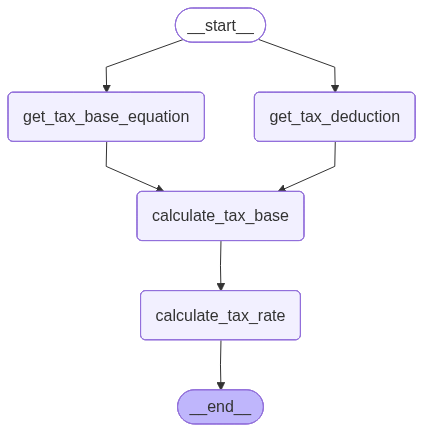

In [37]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
initial_state = {'query': query}
graph.invoke(initial_state)

과세표준: 제공해주신 정보와 과세표준 계산 공식을 바탕으로 과세표준을 계산해드리겠습니다.

**1. 주택 공시가격 합산액 계산:**
*   5억 + 10억 + 20억 = **35억 원**

**2. 납세의무자 유형 가정 및 공제금액 결정:**
*   사용자님께서 3채의 주택을 소유하고 계시므로, "1세대1주택자"에는 해당하지 않습니다. 또한 "법인 또는 법인으로 보는 단체"가 아닌 개인으로 가정합니다.
*   따라서 **"그 외의 경우"**에 해당하여 **9억 원**이 공제됩니다.

**3. 공정시장가액비율:**
*   **60%**

**4. 과세표준 계산:**

*   **과세표준 = MAX(0, 공시가격합산액 - 공제금액) × 공정시장가액비율**
*   과세표준 = MAX(0, 3,500,000,000원 - 900,000,000원) × 0.60
*   과세표준 = MAX(0, 2,600,000,000원) × 0.60
*   과세표준 = 2,600,000,000원 × 0.60
*   **과세표준 = 1,560,000,000원**

**결론:**

사용자님의 주택 공시가격 합산액(35억 원)을 기준으로 계산된 **과세표준은 15억 6천만 원** 입니다.

**참고:**
이 금액은 종합부동산세 계산을 위한 **과세표준**이며, 실제로 납부하실 세액은 이 과세표준에 해당하는 세율을 적용하고 세액공제 등을 거쳐 최종적으로 결정됩니다. (세율 정보는 제공되지 않아 최종 세액 계산은 어렵습니다.)


{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
 'answer': '제공해주신 정보와 과세표준을 바탕으로 종합부동산세를 계산해드리겠습니다.\n\n1.  **납세의무자 유형 확인:**\n    사용자님은 3채의 주택(5억, 10억, 20억)을 소유하고 계시므로, **"납세의무자가 3주택 이상을 소유한 경우"**에 해당합니다.\n\n2.  **과세표준 확인:**\n    계산된 과세표준은 **15억 6천만 원**입니다.\n\n3.  **세율 구간 적용 (3주택 이상 소유자):**\n    과세표준 15억 6천만 원은 **"12억 원 초과 25억 원 이하"** 구간에 해당합니다. 해당 구간의 세율은 **"960만 원 + (12억 원을 초과하는 금액의 1천분의 20)"** 입니다.\n\n4.  **종합부동산세 계산:**\n    *   12억 원 초과 금액: 1,560,000,000원 - 1,200,000,000원 = 360,000,000원\n    *   초과 금액에 대한 세액: 360,000,000원 × (20 / 1,000) = 7,200,000원\n    *   총 종합부동산세액: 9,600,000원 + 7,200,000원 = **16,800,000원**\n\n따라서 사용자님의 종합부동산세는 **1,680만 원**입니다.\n\n**참고:** 이 금액은 과세표준에 세율을 적용하여 산출된 세액이며, 실제 납부할 세액은 여기에 재산세 공제 등이 적용되어 최종 결정됩니다. 다만, 연령별/보유기간별 세액공제는 1세대 1주택자에게만 적용되므로 사용자님께는 해당되지 않습니다.',
 'tax_base_equation': '과세표준 = MAX(0, 공시가격합산액 - 공제금액) × 공정시장가액비율\n\n여기서 공제금액은 다음과 같습니다:\n- 납세의무자유형이 "1세대1주택자"인 경우: 1,200,000,000원\n- 납세의무자유형이 "법인 또는 법인으로 보는 단체"인 경우: 600,000,000원\n